In [3]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

In [4]:
zip_path = "archive (4).zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

dataset/
    Combined Dataset/
        test/
            Mild Impairment/
            Moderate Impairment/
            No Impairment/
            Very Mild Impairment/
        train/
            Mild Impairment/
            Moderate Impairment/
            No Impairment/
            Very Mild Impairment/


In [6]:
train_dir = "dataset/Combined Dataset/train"
test_dir = "dataset/Combined Dataset/test"

print("Training Classes:")
print(os.listdir(train_dir))

print("\nTesting Classes:")
print(os.listdir(test_dir))

Training Classes:
['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']

Testing Classes:
['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']


In [7]:
classes = sorted(os.listdir(train_dir))

print("Classes:")

for i, cls in enumerate(classes):
    print(i, cls)

Classes:
0 Mild Impairment
1 Moderate Impairment
2 No Impairment
3 Very Mild Impairment


In [8]:
print("Number of Training Images:\n")

for cls in classes:
    
    class_path = os.path.join(train_dir, cls)
    
    image_count = len(os.listdir(class_path))
    
    print(cls, ":", image_count)

Number of Training Images:

Mild Impairment : 2560
Moderate Impairment : 2560
No Impairment : 2560
Very Mild Impairment : 2560


In [9]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    
    preprocessing_function=preprocess_input,
    
    rotation_range=10,
    
    width_shift_range=0.1,
    
    height_shift_range=0.1,
    
    zoom_range=0.1,
    
    horizontal_flip=True,
    
    validation_split=0.2
)

In [10]:
train_generator = train_datagen.flow_from_directory(
    
    train_dir,
    
    target_size=(IMG_SIZE, IMG_SIZE),
    
    batch_size=BATCH_SIZE,
    
    class_mode='categorical',
    
    subset='training',
    
    shuffle=True,
    
    seed=42
)

Found 8192 images belonging to 4 classes.


In [11]:
validation_generator = train_datagen.flow_from_directory(
    
    train_dir,
    
    target_size=(IMG_SIZE, IMG_SIZE),
    
    batch_size=BATCH_SIZE,
    
    class_mode='categorical',
    
    subset='validation',
    
    shuffle=False,
    
    seed=42
)

Found 2048 images belonging to 4 classes.


In [12]:
test_datagen = ImageDataGenerator(
    
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    
    test_dir,
    
    target_size=(IMG_SIZE, IMG_SIZE),
    
    batch_size=BATCH_SIZE,
    
    class_mode='categorical',
    
    shuffle=False
)
print(train_generator.class_indices)

Found 1279 images belonging to 4 classes.
{'Mild Impairment': 0, 'Moderate Impairment': 1, 'No Impairment': 2, 'Very Mild Impairment': 3}


In [13]:
base_model = ResNet50(
    
    weights='imagenet',
    
    include_top=False,
    
    input_shape=(224, 224, 3)
)

94765736/94765736 [==============================] - 5s 0us/step


In [14]:
base_model.trainable = False

print("ResNet50 layers frozen successfully!")

ResNet50 layers frozen successfully!


In [15]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(
    
    len(classes),
    
    activation='softmax'
    
)(x)


model = Model(
    
    inputs=base_model.input,
    
    outputs=output
)

In [16]:
model.compile(
    
    optimizer=Adam(learning_rate=0.0001),
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [18]:
early_stop = EarlyStopping(
    
    monitor='val_loss',
    
    patience=3,
    
    restore_best_weights=True
)

In [19]:
EPOCHS = 10

history = model.fit(
    
    train_generator,
    
    validation_data=validation_generator,
    
    epochs=EPOCHS,
    
    callbacks=[early_stop]
)

Epoch 1/10
256/256 [==============================] - 299s 1s/step - loss: 1.1346 - accuracy: 0.5254 - val_loss: 0.8095 - val_accuracy: 0.6357
Epoch 2/10
256/256 [==============================] - 293s 1s/step - loss: 0.7963 - accuracy: 0.6600 - val_loss: 0.7395 - val_accuracy: 0.6577
Epoch 3/10
256/256 [==============================] - 294s 1s/step - loss: 0.7104 - accuracy: 0.7003 - val_loss: 0.7494 - val_accuracy: 0.6411
Epoch 4/10
256/256 [==============================] - 296s 1s/step - loss: 0.6638 - accuracy: 0.7183 - val_loss: 0.7365 - val_accuracy: 0.6558
Epoch 5/10
256/256 [==============================] - 298s 1s/step - loss: 0.6351 - accuracy: 0.7341 - val_loss: 0.6990 - val_accuracy: 0.6553
Epoch 6/10
256/256 [==============================] - 297s 1s/step - loss: 0.6002 - accuracy: 0.7429 - val_loss: 0.7263 - val_accuracy: 0.6577
Epoch 7/10
256/256 [==============================] - 296s 1s/step - loss: 0.5760 - accuracy: 0.7522 - val_loss: 0.7104 - val_accuracy: 0.6567

In [35]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

print("Test Accuracy Percentage:", test_accuracy * 100)

40/40 [==============================] - 22s 546ms/step - loss: 1.0737 - accuracy: 0.4918
Test Loss: 1.0737122297286987
Test Accuracy: 0.4917904734611511
Test Accuracy Percentage: 49.17904734611511


In [28]:
test_generator.reset()

predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_names = list(train_generator.class_indices.keys())

40/40 [==============================] - 23s 563ms/step


In [29]:
print("CLASSIFICATION REPORT\n")

print(
    classification_report(
        
        true_classes,
        
        predicted_classes,
        
        target_names=class_names
    )
)

CLASSIFICATION REPORT

                      precision    recall  f1-score   support

     Mild Impairment       0.27      0.88      0.41       179
 Moderate Impairment       1.00      0.17      0.29        12
       No Impairment       0.70      0.67      0.68       640
Very Mild Impairment       0.57      0.10      0.17       448

            accuracy                           0.49      1279
           macro avg       0.63      0.45      0.39      1279
        weighted avg       0.60      0.49      0.46      1279



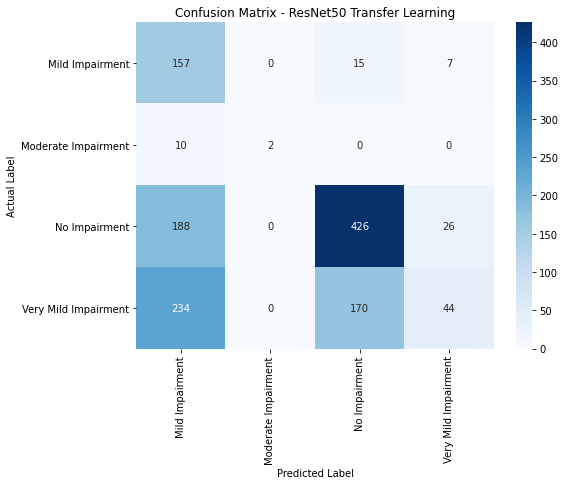

In [30]:
cm = confusion_matrix(
    
    true_classes,
    
    predicted_classes
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    
    cm,
    
    annot=True,
    
    fmt='d',
    
    cmap='Blues',
    
    xticklabels=class_names,
    
    yticklabels=class_names
)

plt.title("Confusion Matrix - ResNet50 Transfer Learning")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

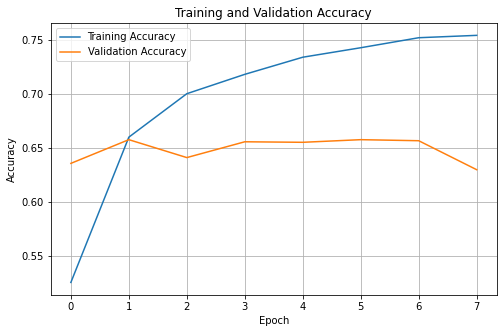

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()

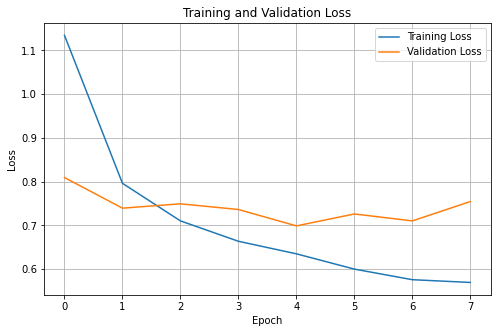

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

In [33]:
model.save("resnet50_transfer_learning_model.keras")

print("Model saved successfully!")

Model saved successfully!
